# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models? <br><br>

A general linear model is linear model which allows for non-linear transformations. It predicts dependent variables determined by a linear combination of independent variables. In general linear models, we have latent variables. A latent variable is a variable which is inferred based on other variables. These latent variables are hidden in the layers of neuro networks, but are necessary in activation functions. These functions calculate the output of the neuro network which is a connection of variables and their relationships with oneanother.

It is advantagious for us to use general linear models because it captures and emulates non-linear patterns/trends to provide more accurate predictions. <br><br>




2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.<br><br>

Categorical cross entropy is a type of loss function which determine the accuracy of classification in multi-class models. Binary cross entropy is a type of loss function that determines the accuracy of classification in a single class which has only two options for classification. There is only a a single probability output in this case rather than a probability distribution. In both of these loss functions, cross entroy loss calcuations are better suited for classification predictions because it is more accurate and faster as it penalizes wrong predictions exponentially and therefore correct itself more quickly. This leads to converging more quickly as the weights of the variables are updated more quickly when the model is sure that it is wrong, and therefore lead to a faster sepparation of classes. <br><br>

3. True or false, and explain: Logistic regression is a linear model.<br><br>

True (ish): Logisitc regressions are linear because they represent the data as a linear combination and the parameters are in linear form. However, there are non-linear transformations used in logistic regressions through the activation function which outputs the probabilities. Therefore, it is classififed as a generalized linear model.

<br><br>
4. True or false, and explain: Logistic regression cannot be used for classification.<br><br>

False: Logisitc regressions actually excel in classifications problems because they take the relationships between the dependent variables with the independent target variable to determine the predicted probability of each class option in the target variable. Logistic regressinos predict based on the class with the highest predicted probability.

<br><br>

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?<br><br>

No, because logisitc regressions use a logit function which takes the log of the odds/probabilities so the as there is one unit of change, the log-odds changes, not the predicted probability which is found through the activation function which is non-linear.

<br><br>

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.<br><br>

False: Logistic regressions are linear for specifically their features as it represents the data as a linear combination of features. Feature engineering is transforming data into meaningful feautures. Logistic regressions need to tranform these linear feature into nonlinear features so nonlinear relationships and probabilities can be determined.

<br><br>

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.<br><br>

False: Logistic regressions are great for classification problems, however, are not usable when the target variable is continuous as there would be classes to calcuate probabilities for. OLS is useful for a continuous target varible as it models the expected value of a continous vairbale with it's linear combination of the dataset.<br><br>

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [650]:
# Q 2.1 and exploration
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('data/data.csv', sep=';')
df.head()

df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [651]:
# Q 2.1 and exploration

df['Target'].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [652]:
# Q 2.1 and exploration

df = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder',
         'Age at enrollment', 'Curricular units 1st sem (approved)',
         'Target']]
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [653]:
# Q2.2

from sklearn.linear_model import LogisticRegression

x = df.drop(['Curricular units 1st sem (approved)', 'Target' ], axis=1)
y = df[['Target']]

logreg = LogisticRegression(
    solver='lbfgs',
    max_iter=5000,
    multi_class='multinomial'
)

logreg = logreg.fit(x, y)

mnl_coef = pd.DataFrame(logreg.coef_ , index=logreg.classes_)
mnl_coef = mnl_coef.set_axis(logreg.feature_names_in_,axis=1)
mnl_coef


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment
Dropout,0.309030,-1.682221,-0.633771,0.033086
Enrolled,0.269880,0.316375,-0.242308,-0.016066
Graduate,-0.578911,1.365846,0.876080,-0.017020


The variable with the highest probability of dropouts is Debtor and the lowest is Scholarship holder. Being up to date on tuition is the second most influencial variable that reduces dropout rates.  

On average, being up to date on tuition changes the predicted probability of dropout by 0.32121844680263767%


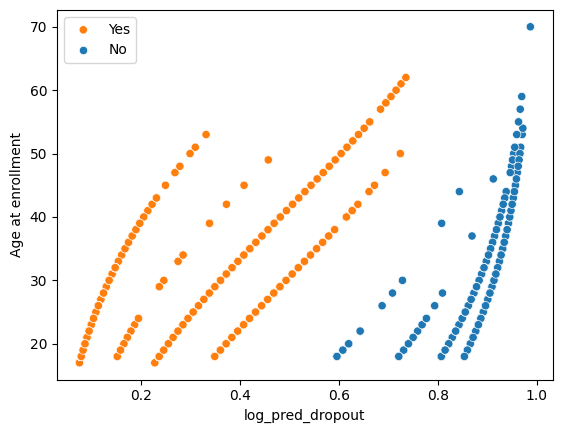

In [654]:
# Q 2.3

probs = logreg.predict_proba(x)
df['log_pred_dropout'] = probs[:, [0]]

sns.scatterplot(df, x = 'log_pred_dropout', y = 'Age at enrollment', hue = 'Tuition fees up to date' )
plt.legend(['Yes', 'No'])
print(f'On average, being up to date on tuition changes the predicted probability of dropout by {df['log_pred_dropout'].mean()}%')

The ages where being up to date on tuition seem to reduce dropout probability the most is ages 18-40. This is show by the orange data points which have a positive correlation with dropout rates.

In [655]:
# Q 2.4

tab = pd.crosstab(logreg.predict(x), df['Target'])
tab


Target,Dropout,Enrolled,Graduate
row_0,,,
Dropout,659,146,194
Graduate,762,648,2015


(659+2015)/(659+762+146+648+194+2015)*100 = 60.44% accurate.

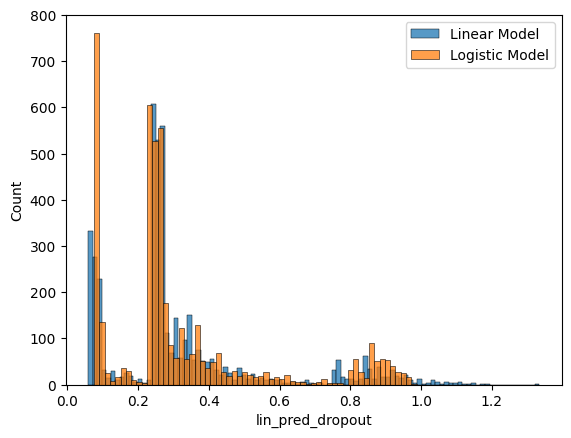

In [656]:
# Q 2.5

from sklearn.linear_model import LinearRegression

x = df.drop(['Curricular units 1st sem (approved)', 'Target', 'log_pred_dropout'], axis=1)
y_prob_dropout = df['log_pred_dropout']

linreg = LinearRegression()

linreg = linreg.fit(x, y_prob_dropout)
df['lin_pred_dropout'] = linreg.predict(x)

sns.histplot(data = df, x = 'lin_pred_dropout', label='Linear Model')
sns.histplot(data = df, x = 'log_pred_dropout', label='Logistic Model')

plt.legend()

In scanning the histogram above, we can see that the logistic and linear models have very similar predictions, except for at around 10% where the logisitic model predicts a much higher count than the linear model.

### Q 2.6
The students that are most at-risk of dropping out are those that have outstanding debt. We also find that students with scholarships are the least at-risk to drop out. From knowing these two trends, we can predict that supplying students with outstanding with scholarship opportunities can help decrease the rate at which they dropout.

In [657]:
# Q 2.7


#hard classification
x = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y = df['Target']

logreg = LogisticRegression(
    solver='lbfgs',
    max_iter=5000,
    multi_class='multinomial'
)

logreg = logreg.fit(x, y)

df['log_hard_class'] = logreg.predict(x)
tab = pd.crosstab(df['log_hard_class'], df['Target'])
print(tab)

true = tab.loc['Dropout', 'Dropout'] + tab.loc['Graduate', 'Graduate']
total = tab.values.sum()
accuracy = true/total
print(f'The accuracy of the hard classification is {accuracy}.')

print(logreg.classes_[0]) #dropout
print(logreg.classes_[1]) #enrollment
print(logreg.classes_[2]) #graduated

#prob class

df['prob_log_drop'] = logreg.predict_proba(x)[:, 0]
df['prob_log_enroll'] = logreg.predict_proba(x)[:, 1]
df['prob_log_grad'] = logreg.predict_proba(x)[:, 2]

print(f'average probability prediction of dropout is {df['prob_log_drop'].mean()}')
print(f'average probability prediction of enrollment is {df['prob_log_enroll'].mean()}')
print(f'average probability prediction of graduated is {df['prob_log_grad'].mean()}')

df[['prob_log_drop', 'prob_log_enroll', 'prob_log_grad']]

Target          Dropout  Enrolled  Graduate
log_hard_class                             
Dropout            1054       280       146
Graduate            367       514      2063
The accuracy of the hard classification is 0.7045660036166366.
Dropout
Enrolled
Graduate
average probability prediction of dropout is 0.32122294188826644
average probability prediction of enrollment is 0.17947367985866028
average probability prediction of graduated is 0.4993033782530733


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,prob_log_drop,prob_log_enroll,prob_log_grad
0,0.680547,0.210464,0.108989
1,0.695414,0.146043,0.158543
2,0.952988,0.041199,0.005813
3,0.117808,0.176983,0.705209
4,0.184227,0.212669,0.603104
...,...,...,...
4419,0.184227,0.212669,0.603104
4420,0.784988,0.149758,0.065253
4421,0.071938,0.140644,0.787418
4422,0.184227,0.212669,0.603104


### Q 2.7 continued...
The hard classifcation does not predict enrolled whereas the prediction probability does predict a probability the student is enrolled. The hard class does not because there is no student where the probability that they are enrolled is higher than either dropout or enrolled, and therefore no student is ever classed as such. We are able to illustrate a better picture of students' enrollment status through the prediction probability because we can see the breakdown in likihood for each class, so we know that there are students in each category.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [658]:
# Q 3.1
df = pd.read_csv('data/cirrhosis.csv')
df = df[['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']]

df['Edema'] = df['Edema'].map({'N': 0, 'Y': 1, 'S': 1})
df['Drug'] = df['Drug'].map({'D-penicillamine': 0, 'Placebo': 1})
df['Status'] = df['Status'].map({'C': 1, 'CL': 1, 'D': 0})


df.isna().sum() # there are 44 na values in the Edema variable column,
                # 106 na values in the Drug variable column

# Decided to drop rows with na values because Logistic Regression model
# can not work with datasets that have na values

print(f'The shape before dropping na values is {df.shape}')

df = df.dropna()

df.isna().sum() #checking that nas are gone now

print(f'The shape after dropping na values is {df.shape}')

The shape before dropping na values is (418, 5)
The shape after dropping na values is (312, 5)


In [659]:
# Q 3.2

x = df[['Edema', 'Drug', 'Bilirubin']]
y = df['Status']

logreg = LogisticRegression(
    solver='lbfgs',
    max_iter=5000)

logreg = logreg.fit(x, y)

ovr_coef = pd.DataFrame(logreg.coef_ , index=['Alive (1) vs Dead (0)'])
ovr_coef = ovr_coef.set_axis(logreg.feature_names_in_,axis=1)
ovr_coef

,Edema,Drug,Bilirubin
Alive (1) vs Dead (0),-0.954056,0.219972,-0.353204


Drug variable coefficient is positive, which shows that the model indicates that the drug does improve the survival probability. However, with Edema, the coefficient is relatively large and negative. Therefore, the survival probability decreases with Edema.

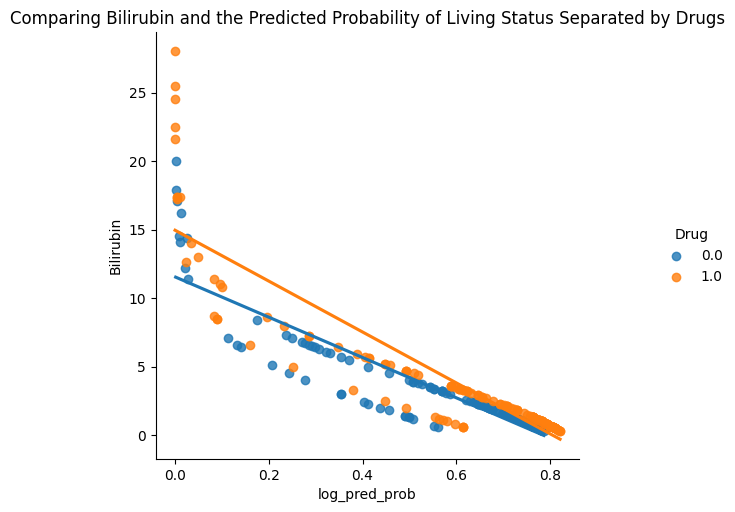

In [660]:
# Q 3.3

df['log_pred_prob'] = logreg.predict_proba(x)[:, [1]]

sns.lmplot(data=df, x="log_pred_prob", y="Bilirubin", hue="Drug", ci=None)
plt.title('Comparing Bilirubin and the Predicted Probability of Living Status Separated by Drugs')
plt.show()



### Q 3.3 continued...
In the scatterplot, it shows that when there are more liver byproducts, specifically higher than 10, the predicted probability of being alive decreases drastically. From the ovr_coef dataframe, we see that there is a negative coefficient for Bilirubin of -0.3532 which is the probability ratio which supports our graph's findings.

On average, taking the drug increases their probability of survival by a 0.219972 ratio odd, as shown in the ovr_coef dataframe.

In [661]:
# Q 3.4
tab = pd.crosstab(logreg.predict(x), df['Status'])
tab

Status,0,1
row_0,,
0,62,17
1,63,170


In [662]:
true = tab.loc[0, 0] + tab.loc[1, 1]
total = tab.values.sum()
accuracy = true/total
print(f'The accuracy of the hard classification is {accuracy*100}%.')


The accuracy of the hard classification is 74.35897435897436%.


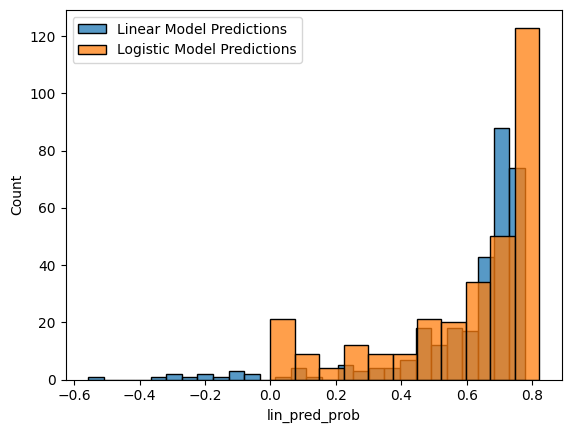

In [663]:
# Q 3.5

lin = LinearRegression()
lin = lin.fit(x, y)
df['lin_pred_prob'] = lin.predict(x)
df['lin_pred_prob']

sns.histplot(df, x = 'lin_pred_prob', label = 'Linear Model Predictions')
sns.histplot(df, x = 'log_pred_prob', label = 'Logistic Model Predictions')
plt.legend()
plt.show()

Both the distribution of probability counts for the linear and logistic models are skewed left. The linear model shows to have fewer high probability predictions than the logistic, however, has a greater variation of prediction probabilities.

In [664]:
# Q 3.6

x = df[['Edema', 'Bilirubin']]
y = df['Stage']

logreg = LogisticRegression(solver = 'lbfgs', max_iter = 5000, multi_class = 'multinomial')
logreg = logreg.fit(x, y)
df['log_pred_stage'] = logreg.predict(x)
df['log_pred_prob_stage'] = logreg.predict_proba(x)[:, 1]

tab = pd.crosstab(df['log_pred_stage'], df['Stage'])
print(tab)

true = tab.loc[3.0, 3.0] + tab.loc[4.0, 4.0]
total = tab.values.sum()
accuracy = true / total
accuracy


print(f'The accuracy of the hard classification is {accuracy}.')



print(logreg.classes_[0]) #dropout
print(logreg.classes_[1]) #enrollment
print(logreg.classes_[2]) #graduated
print(logreg.classes_[3]) #graduated


#prob class

df['prob_log_1'] = logreg.predict_proba(x)[:, 0]
df['prob_log_2'] = logreg.predict_proba(x)[:, 1]
df['prob_log_3'] = logreg.predict_proba(x)[:, 2]
df['prob_log_4'] = logreg.predict_proba(x)[:, 3]

print(f'average probability prediction of state one is {df['prob_log_1'].mean()}')
print(f'average probability prediction of state two is {df['prob_log_2'].mean()}')
print(f'average probability prediction of state three is {df['prob_log_3'].mean()}')
print(f'average probability prediction of state four is {df['prob_log_4'].mean()}')

df[['prob_log_1', 'prob_log_2', 'prob_log_3', 'prob_log_4']]

Stage           1.0  2.0  3.0  4.0
log_pred_stage                    
3.0              16   61  101   73
4.0               0    6   19   36
The accuracy of the hard classification is 0.4391025641025641.
1.0
2.0
3.0
4.0
average probability prediction of state one is 0.05128640412611334
average probability prediction of state two is 0.21473842493611217
average probability prediction of state three is 0.38463113096968965
average probability prediction of state four is 0.3493440399680848


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,prob_log_1,prob_log_2,prob_log_3,prob_log_4
0,0.000010,0.042165,0.233385,0.724440
1,0.073149,0.253002,0.399710,0.274140
2,0.025474,0.154655,0.323327,0.496544
3,0.020216,0.149972,0.322999,0.506813
4,0.020660,0.226228,0.424040,0.329073
...,...,...,...,...
307,0.105252,0.256343,0.384457,0.253948
308,0.105252,0.256343,0.384457,0.253948
309,0.053035,0.247768,0.409291,0.289906
310,0.045039,0.244545,0.413076,0.297340


### Q3.6 continued...

The hard classification does not predict every class: the model only predicts stage 3 and 4 and predicting no patient with stage 1 or 2. This is because the probability of stage 1 and 2 for each patient is never the highest probability. However, with the predicted probabilities, we can see the probability of each class for every patient.



**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?